In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Objective: Explore the dataset to identify patterns, relationships, and business insights that influence customer churn.

In [15]:
df=pd.read_csv("customer.csv")

In [16]:
df["Churn Value"].value_counts() # this is actually the output column

Churn Value
0    5174
1    1869
Name: count, dtype: int64

In [17]:
df["Churn Value"].value_counts(normalize=True)*100

Churn Value
0    73.463013
1    26.536987
Name: proportion, dtype: float64

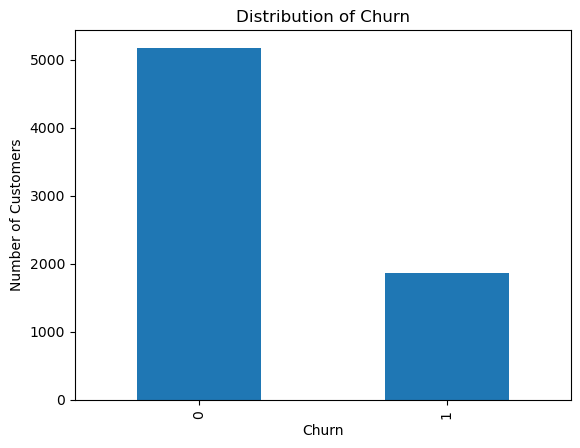

In [18]:
df["Churn Value"].value_counts().plot(
    kind="bar"
)

plt.title("Distribution of Churn")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.show()

## Observation
 * Approximately 26.5% of customers churned, while 73.5% remained.
 * This indicates a moderate class imbalance that should be considered during model evaluation.

In [76]:
df.isnull().sum()

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges          11
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

* Only Churn Reason contains missing values because it is available only for customers who have churned

In [77]:
df[["Monthly Charges", "Tenure Months", "Total Charges"]]

,Monthly Charges,Tenure Months,Total Charges
0,53.85,2,108.15
1,70.70,2,151.65
2,99.65,8,820.50
3,104.80,28,3046.05
4,103.70,49,5036.30
...,...,...,...
7038,21.15,72,1419.40
7039,84.80,24,1990.50
7040,103.20,72,7362.90
7041,29.60,11,346.45


In [99]:
df.groupby("Churn Label")[["Monthly Charges",
                           "Tenure Months",
                           "Total Charges"]].agg(["mean","median"])

Monthly Charges         Tenure Months        Total Charges  \
                       mean  median          mean median          mean   
Churn Label                                                              
No                61.265124  64.425     37.569965   38.0   2555.344141   
Yes               74.441332  79.650     17.979133   10.0   1531.796094   

                      
              median  
Churn Label           
No           1683.60  
Yes           703.55

## observation
   customer with higher Monthly Charges lower Tenure Months and lower Total Charges has higher proportion of churn than with lower Monthly Charges higher Tenure and higher Total Charges

# Numerical Feature Analysis

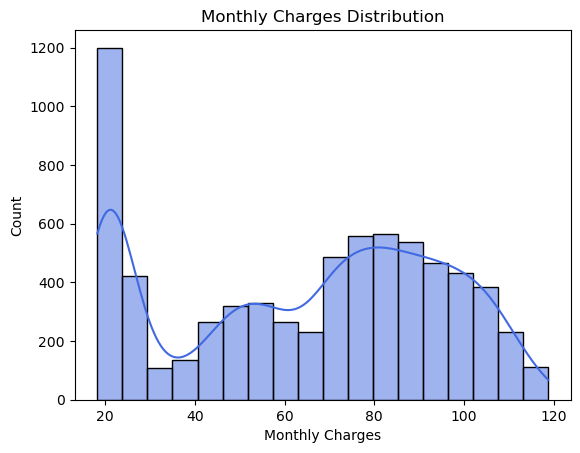

In [37]:
sns.histplot(df["Monthly Charges"],kde=True, color="royalblue")
plt.title("Monthly Charges Distribution")
plt.show()

* High Concentration at Lower Values: There is a significant spike of customers concentrated at the lowest end of the spectrum, specifically around $20. This indicates a large segment of users subscribed to basic, low-cost plans.

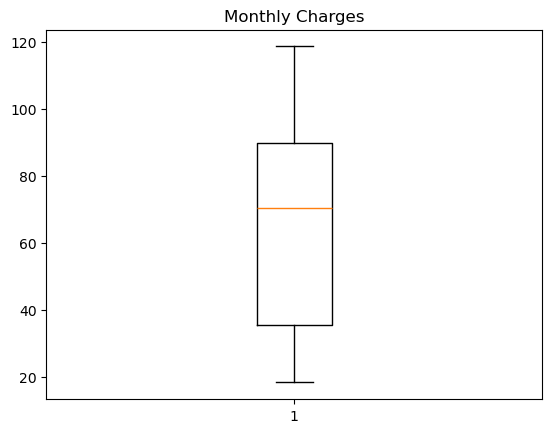

In [78]:
plt.boxplot(df["Monthly Charges"])
plt.title("Monthly Charges")
plt.show()

* There is no outliers in the column Monthly Charges

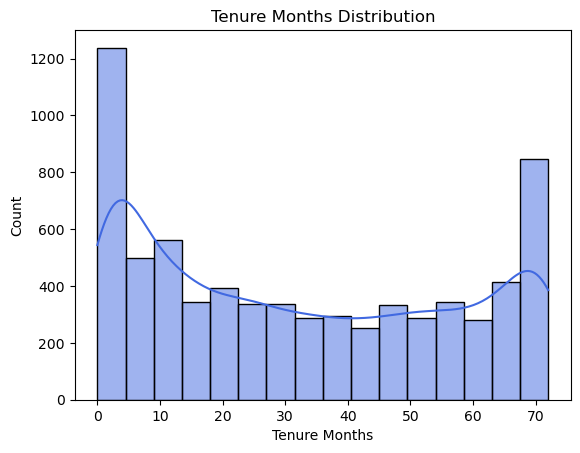

In [79]:
sns.histplot(df["Tenure Months"],kde=True, color="royalblue")
plt.title("Tenure Months Distribution")
plt.show()

* The mid-term tenure (20–60 months) remains uniform and stable.

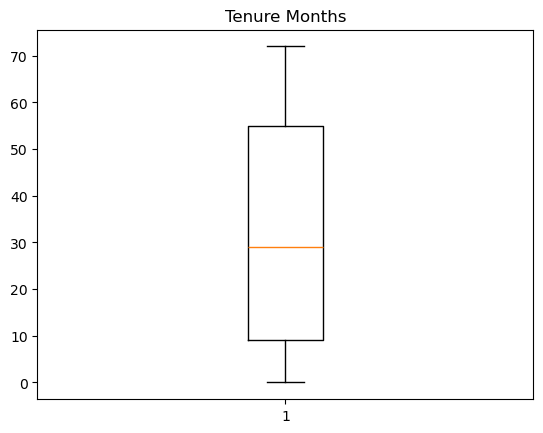

In [80]:
plt.boxplot(df["Tenure Months"])
plt.title("Tenure Months")
plt.show()

* There is no outliers in the column Tenure Months

In [92]:
df = pd.read_csv("customer.csv")

df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

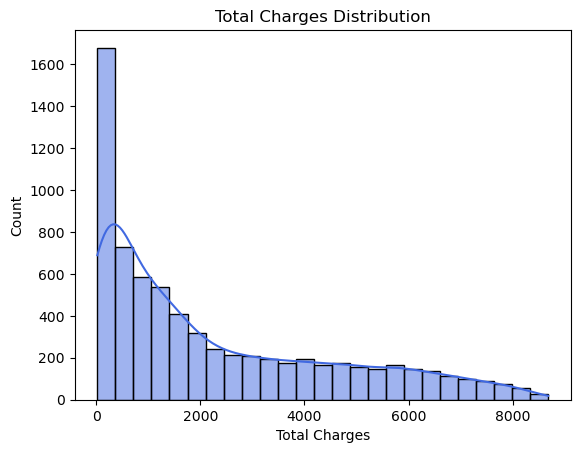

In [93]:
sns.histplot(df["Total Charges"],kde=True, color="royalblue")
plt.title("Total Charges Distribution")
plt.show()

## Observation
* The right-skewed distribution suggests that only a small proportion of customers contribute disproportionately to the company's lifetime revenue. Retaining these high-value customers could have a significant impact on revenue.

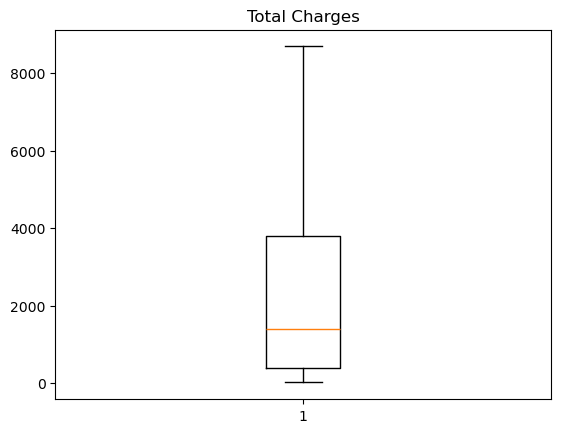

In [96]:
plt.boxplot(df["Total Charges"].dropna())
plt.title("Total Charges")
plt.show()

* There is no outliers in the column Total Charges

# Categorical Feature Analysis

<Axes: xlabel='Contract'>

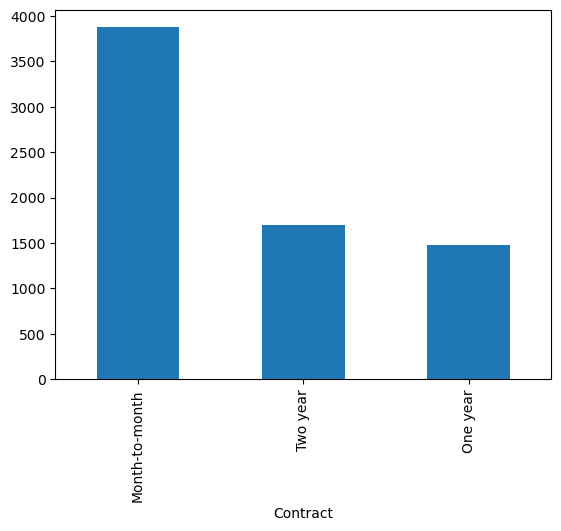

In [58]:
df["Contract"].value_counts().plot(kind="bar")

## Observation
  * Customers with month-to-month contracts have a noticeably higher proportion of churn than those with one-year or two-year contracts.
## Business Insight
  * The company could reduce churn by promoting long-term contracts through pricing incentives or loyalty benefits.

<Axes: xlabel='Gender'>

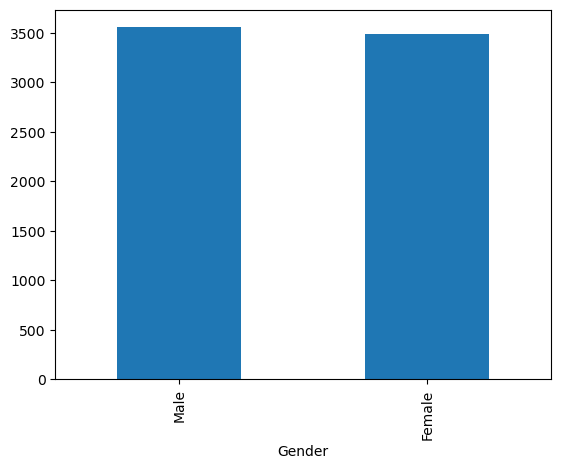

In [60]:
df["Gender"].value_counts().plot(kind="bar")

* No. of male and female is almost equal

<Axes: xlabel='Partner'>

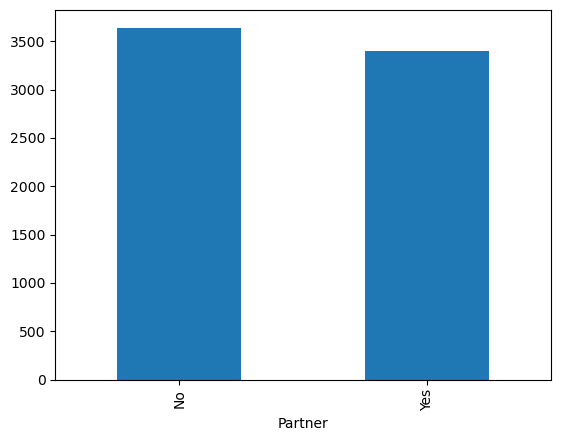

In [61]:
df["Partner"].value_counts().plot(kind="bar")

<Axes: xlabel='Dependents'>

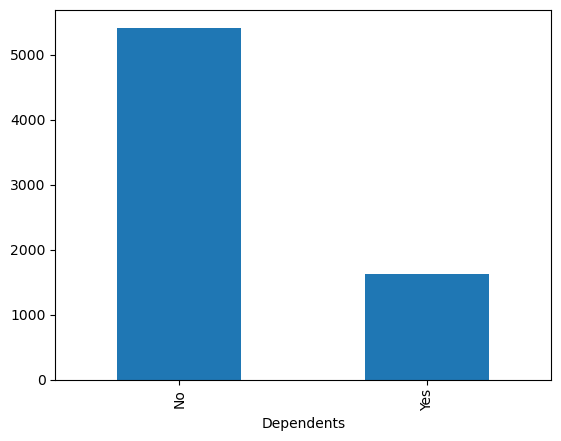

In [62]:
df["Dependents"].value_counts().plot(kind="bar")

<Axes: xlabel='Phone Service'>

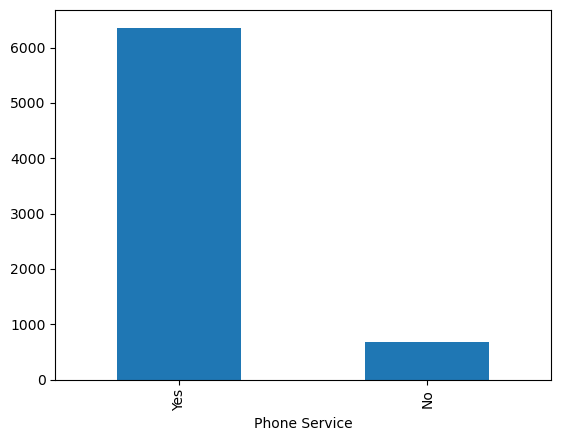

In [63]:
df["Phone Service"].value_counts().plot(kind="bar")

* Only few customers don't have phone service

<Axes: xlabel='Multiple Lines'>

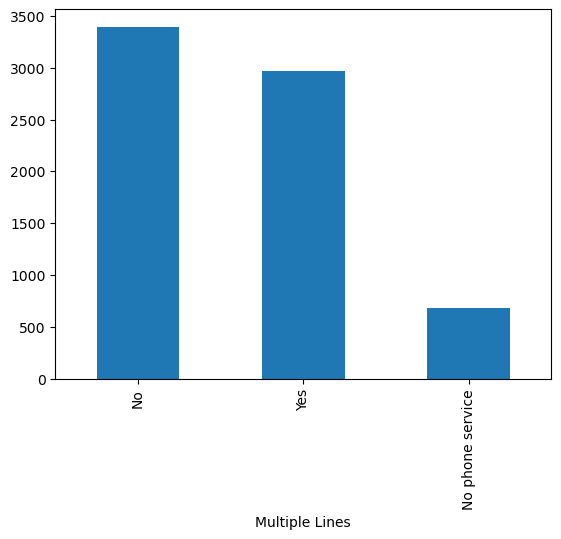

In [64]:
df["Multiple Lines"].value_counts().plot(kind="bar")

<Axes: xlabel='Internet Service'>

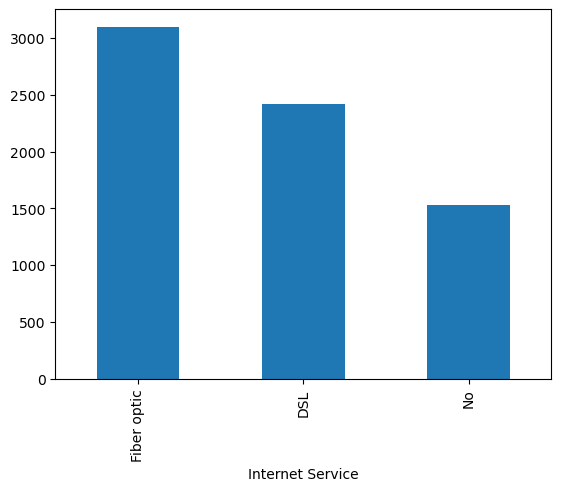

In [65]:
df["Internet Service"].value_counts().plot(kind="bar")

<Axes: xlabel='Online Security'>

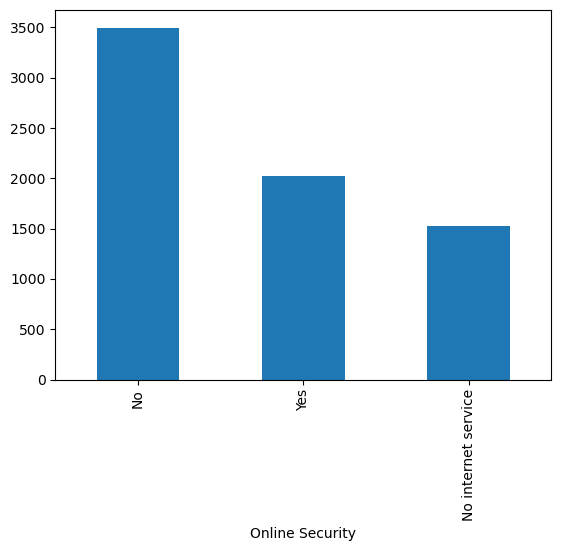

In [66]:
df["Online Security"].value_counts().plot(kind="bar")

<Axes: xlabel='Online Backup'>

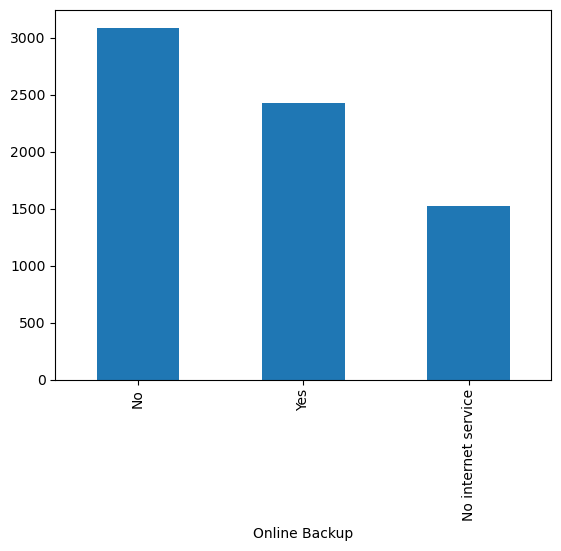

In [67]:
df["Online Backup"].value_counts().plot(kind="bar")

<Axes: xlabel='Device Protection'>

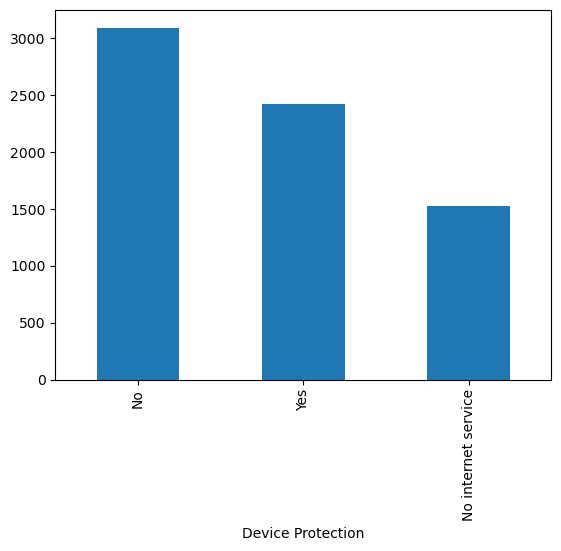

In [68]:
df["Device Protection"].value_counts().plot(kind="bar")

<Axes: xlabel='Tech Support'>

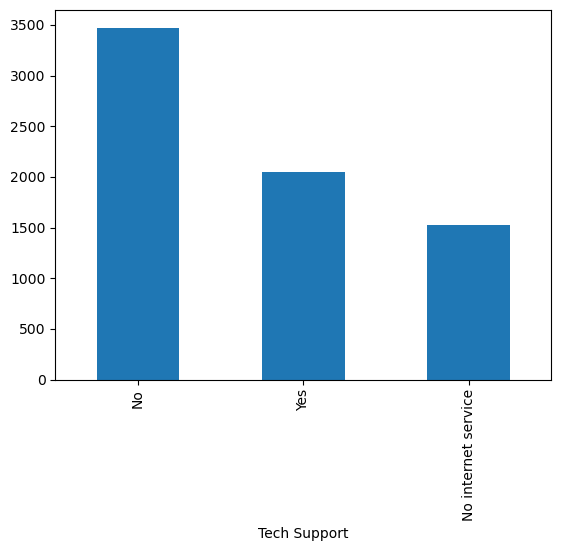

In [69]:
df["Tech Support"].value_counts().plot(kind="bar")

<Axes: xlabel='Streaming TV'>

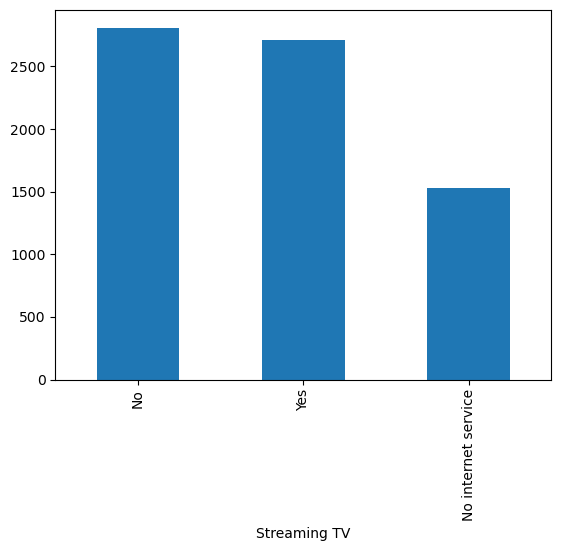

In [70]:
df["Streaming TV"].value_counts().plot(kind="bar")

<Axes: xlabel='Streaming Movies'>

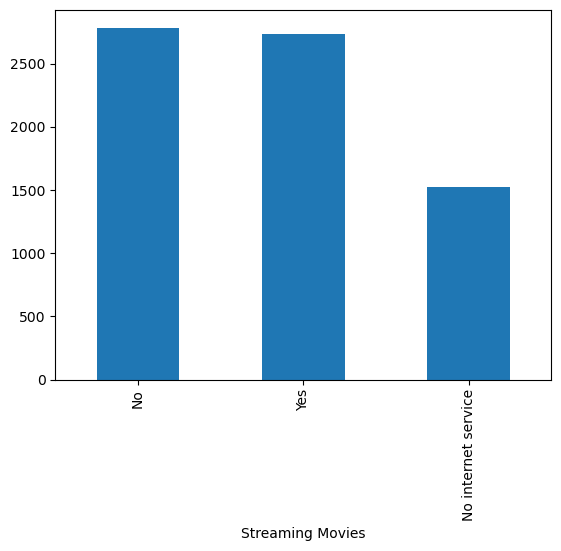

In [71]:
df["Streaming Movies"].value_counts().plot(kind="bar")

<Axes: xlabel='Paperless Billing'>

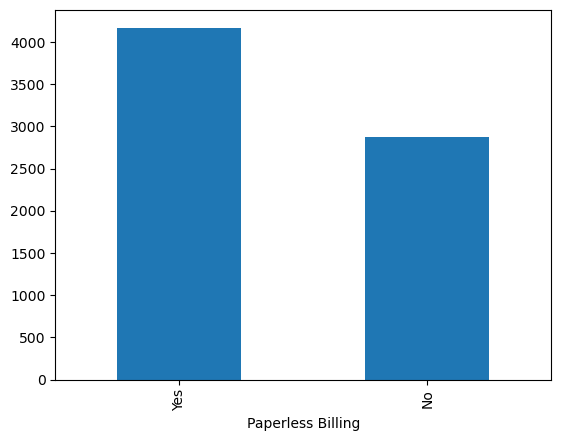

In [74]:
df["Paperless Billing"].value_counts().plot(kind="bar")

<Axes: xlabel='Payment Method'>

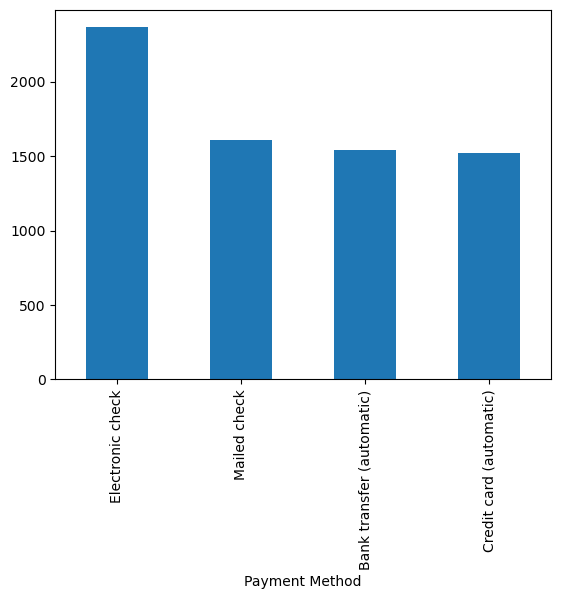

In [73]:
df["Payment Method"].value_counts().plot(kind="bar")

* Electronic check Payment Method used more by the customers than the other methods

# Correlation Heatmap

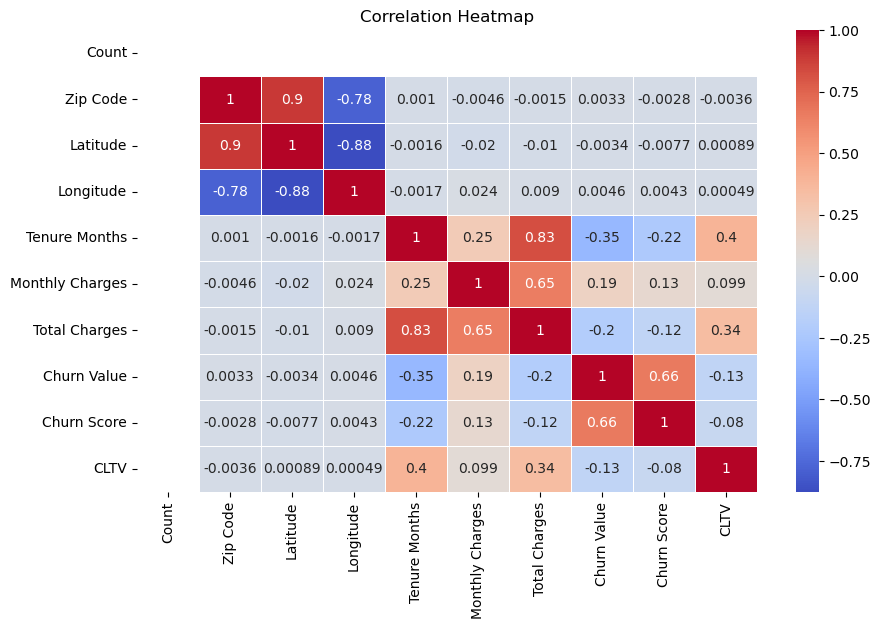

In [142]:
plt.figure(figsize=(10,6))

corr = df.select_dtypes(include="number").corr()

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

## Observations:
    • 'Tenure Months' and 'Total Charges' show a strong positive correlation, indicating that customers with longer tenures generally accumulate higher total charges.
    
    • 'Monthly Charges' has a moderate positive correlation with 'Total Charges', suggesting that higher monthly billing contributes to greater overall spending.
    
    • 'Churn Value' has a negative correlation with 'Tenure Months', implying that customers who have been with the company for a longer period are less likely to churn.
    
    • 'Monthly Charges' exhibits a positive correlation with 'Churn Value', indicating that customers with higher monthly charges are relatively more likely to leave the service.
    
    • Most other numerical features show weak correlations, suggesting limited linear relationships among them.
    
    • No pair of numerical features (except 'Tenure Months' and 'Total Charges') exhibits extremely high correlation, indicating that multicollinearity is unlikely to be a significant concern for model development.

# Churn vs Features

In [100]:
contract_churn = pd.crosstab(
    df["Contract"],
    df["Churn Label"],
    normalize="index"
) * 100

contract_churn

Churn Label,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.730482,11.269518
Two year,97.168142,2.831858


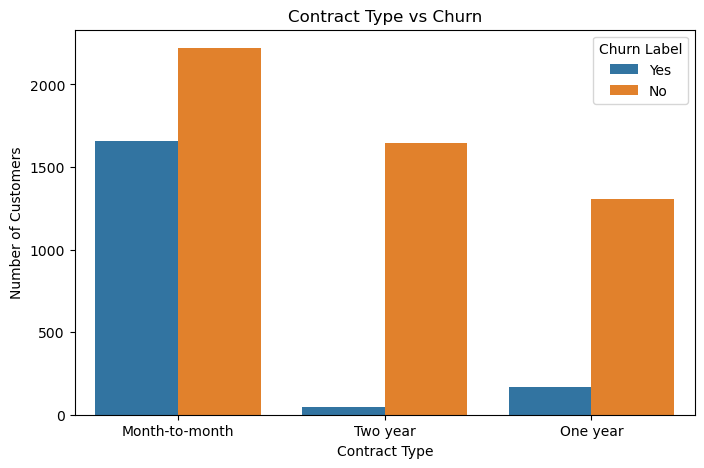

In [83]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, x="Contract", hue="Churn Label")

plt.title("Contract Type vs Churn")
plt.xlabel("Contract Type")
plt.ylabel("Number of Customers")

plt.show()

### Observation
        * Month-to-month customers appear to churn much more frequently
### Business Insight
        * Encourage customers to switch to annual contracts through discounts or loyalty programs.

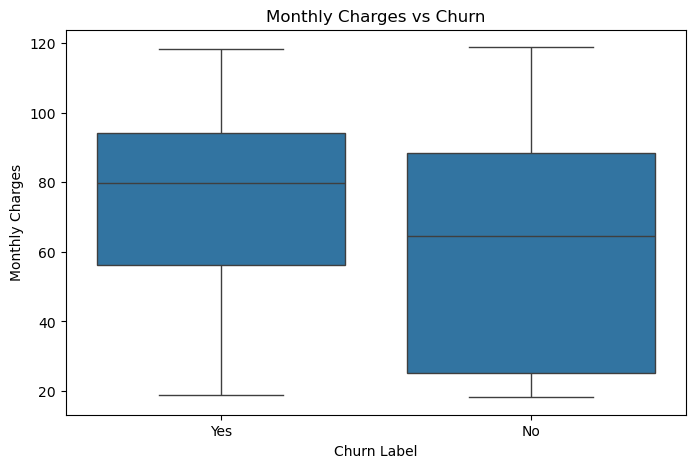

In [102]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x="Churn Label", y="Monthly Charges")

plt.title("Monthly Charges vs Churn")

plt.show()

Text(0.5, 1.0, 'Tenure Months vs Churn')

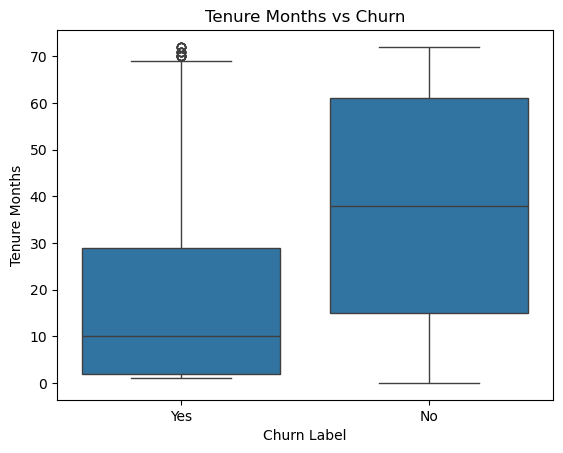

In [103]:
sns.boxplot(
    data=df,
    x="Churn Label",
    y="Tenure Months"
)
plt.title("Tenure Months vs Churn")

* Customers with shorter tenure are significantly more likely to churn than long-term customers.

In [125]:
pd.crosstab(
    df["Internet Service"],
    df["Churn Label"],
    normalize="index"
)*100



Churn Label,No,Yes
Internet Service,,
DSL,81.040892,18.959108
Fiber optic,58.107235,41.892765
No,92.595020,7.404980


Text(0.5, 1.0, 'Internet Service vs Churn')

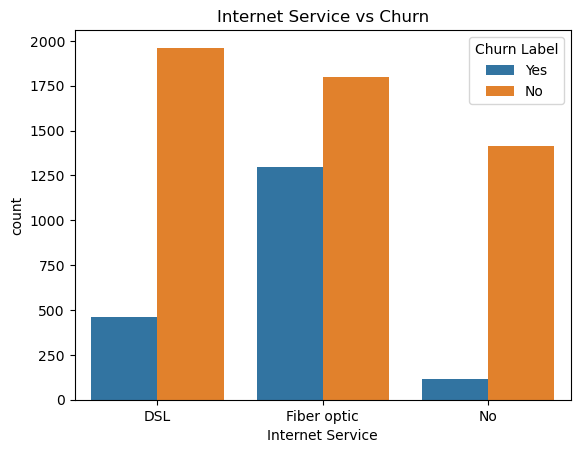

In [104]:
sns.countplot(
    data=df,
    x="Internet Service",
    hue="Churn Label"
)
plt.title("Internet Service vs Churn")

* Customer with fiber optic internet service have a noticeably higher proportion of churn than with DSL or no internet service

In [126]:
pd.crosstab(
    df["Tech Support"],
    df["Churn Label"],
    normalize="index"
)*100

Churn Label,No,Yes
Tech Support,,
No,58.364526,41.635474
No internet service,92.595020,7.404980
Yes,84.833659,15.166341


Text(0.5, 1.0, 'Tech Support vs Churn')

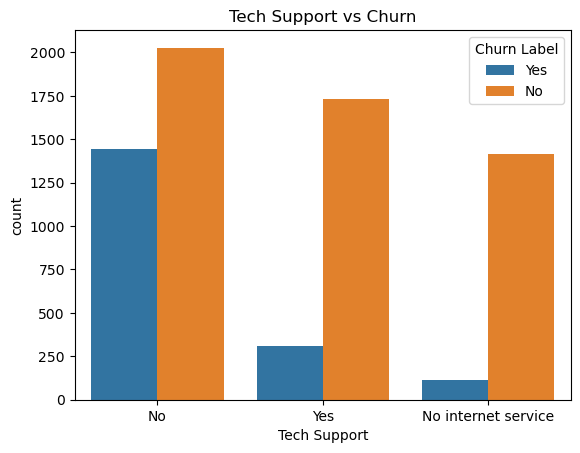

In [107]:
sns.countplot(
    data=df,
    x="Tech Support",
    hue="Churn Label"
)
plt.title("Tech Support vs Churn")

* Customers without technical support exhibit a substantially higher churn rate than customers who receive technical support.

In [124]:
payment = pd.crosstab(
    df["Payment Method"],
    df["Churn Label"],
    normalize="index"
)*100

payment

Churn Label,No,Yes
Payment Method,,
Bank transfer (automatic),83.290155,16.709845
Credit card (automatic),84.756899,15.243101
Electronic check,54.714588,45.285412
Mailed check,80.893300,19.106700


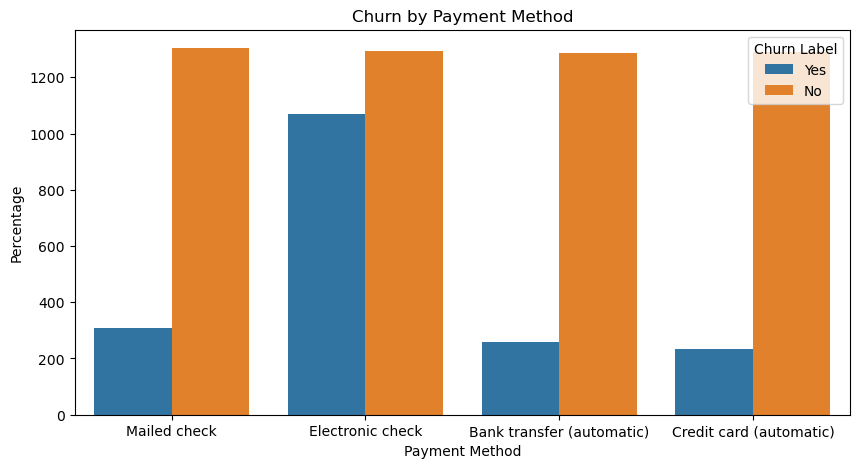

In [122]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=df,
    x=df["Payment Method"],
    hue=df["Churn Label"],
)

plt.ylabel("Percentage")
plt.title("Churn by Payment Method")
plt.show()

* Electronic Check payment method used by the customer has greater possibility of getting churn than the customers used other payment method

In [128]:
pd.crosstab(
    df["Senior Citizen"],
    df["Churn Label"],
    normalize="index"
)*100


Churn Label,No,Yes
Senior Citizen,,
No,76.393832,23.606168
Yes,58.318739,41.681261


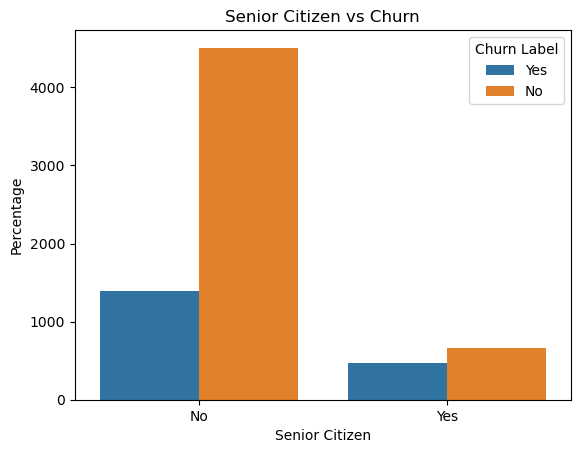

In [130]:
sns.countplot(
    data=df,
    x=df["Senior Citizen"],
    hue=df["Churn Label"]
)

plt.title("Senior Citizen vs Churn")
plt.ylabel("Percentage")
plt.show()

### Observation

- Senior citizens exhibit a higher churn rate compared to non-senior customers.
- This suggests age may be an important factor influencing customer retention.

In [132]:
pd.crosstab(
    df["Partner"],
    df["Churn Label"],
    normalize="index"
)*100

Churn Label,No,Yes
Partner,,
No,67.042021,32.957979
Yes,80.335097,19.664903


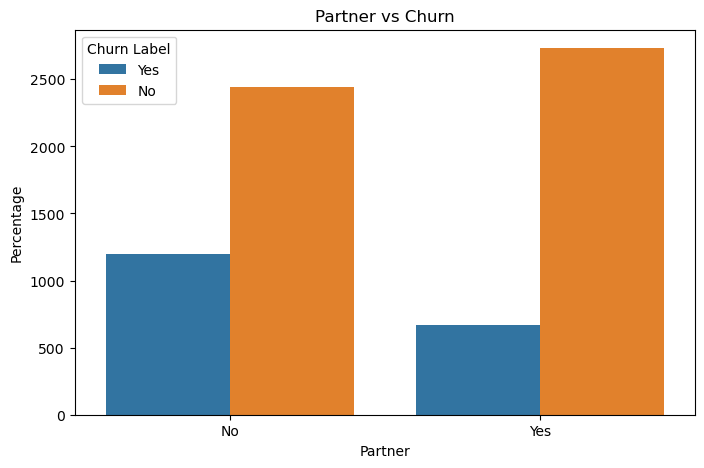

In [137]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x=df["Partner"],
    hue=df["Churn Label"],
)

plt.title("Partner vs Churn")
plt.ylabel("Percentage")
plt.show()

In [138]:
pd.crosstab(
    df["Dependents"],
    df["Churn Label"],
    normalize="index"
)*100

Churn Label,No,Yes
Dependents,,
No,67.448301,32.551699
Yes,93.484942,6.515058


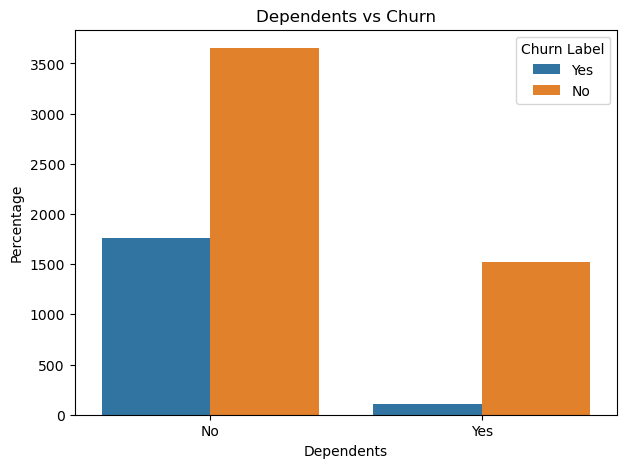

In [139]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x=df["Dependents"],
    hue=df["Churn Label"]
)

plt.title("Dependents vs Churn")
plt.ylabel("Percentage")
plt.show()

* Customers without dependents appear to churn more frequently than customers with dependents

## Key Insights

- Customers on month-to-month contracts have the highest churn rate.
- Customers with longer tenure are less likely to churn.
- Higher monthly charges are associated with increased churn.
- Customers without Tech Support or Online Security tend to churn more frequently.
- Senior citizens show a relatively higher churn rate.
- Customers without partners or dependents are more likely to churn.